# 2 · Geometry

**What you will do:** project 28 000-dimensional trials into two dimensions with five different methods, then refuse to judge the result by eye.

**What you should take away:** every embedding is an argument, not a picture. The deliverable of this notebook is a *table*, and the control that makes the table mean something is running the same pipeline on shuffled labels.

Runtime: two to three minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from compbio2026 import data, geometry, plotting

plotting.apply_style()
rng = np.random.default_rng(2026)

shd = data.load("train")

# Ten English digits, a fixed random subset. Smaller and cleaner than all 20
# classes, and it avoids conflating "which digit" with "which language".
subset = rng.choice(np.flatnonzero(shd.english_mask()), size=1500, replace=False)

X, y, t = data.build_design_matrix(shd, bin_ms=25.0, t_max_ms=800.0, smooth_ms=10.0, trials=subset)
Xf = data.flatten(X)
words = [data.DIGIT_KEYS[c] for c in range(10)]

print("X ", X.shape, " -> flattened", Xf.shape)

X  (1500, 700, 32)  -> flattened (1500, 22400)


## PCA first, always

Fast, deterministic, and it tells you the effective dimensionality. If PCA already separates the classes, most of the nonlinear machinery is decoration.

participation ratio  19.8   (out of 22,400 raw features)
components for 90% variance: 51


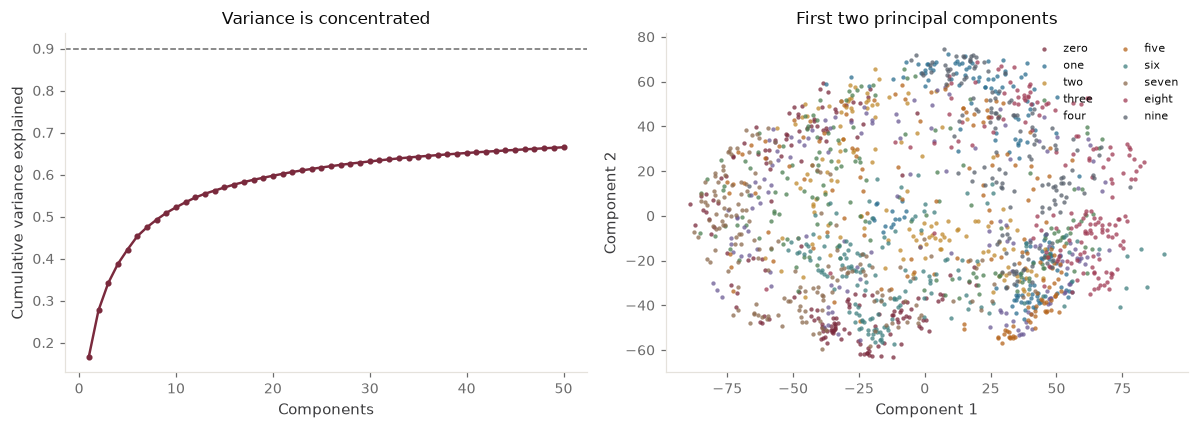

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50).fit(Xf)
Z50 = pca.transform(Xf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, 51), np.cumsum(pca.explained_variance_ratio_),
             marker="o", ms=3, color=plotting.ACCENT)
axes[0].axhline(0.9, ls="--", lw=1, color=plotting.INK_MUTED)
axes[0].set_xlabel("Components")
axes[0].set_ylabel("Cumulative variance explained")
axes[0].set_title("Variance is concentrated")

plotting.embedding(Z50[:, :2], y, labels=data.DIGIT_KEYS, ax=axes[1], s=8)
axes[1].legend(ncol=2, fontsize=7)
axes[1].set_title("First two principal components")
fig.tight_layout()

pr = geometry.participation_ratio(Xf)
print(f"participation ratio  {pr:.1f}   (out of {Xf.shape[1]:,} raw features)")
print(f"components for 90% variance: {np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.9) + 1}")

The **participation ratio** is the effective dimensionality, `(Σλ)² / Σλ²` over the covariance eigenvalues. It needs no arbitrary threshold, unlike "components to reach 90 % variance".

A population of 700 channels × 32 time bins moves on a surface of effective dimension in the tens. That is the central fact this project is built on.

## Five methods, one figure

Each is fitted on the same 50 PCs, which is standard practice and keeps the nonlinear methods tractable.

In [3]:
from sklearn.manifold import Isomap, SpectralEmbedding, TSNE
import umap

embeddings = {
    "PCA":      Z50[:, :2],
    "Isomap":   Isomap(n_components=2, n_neighbors=15).fit_transform(Z50),
    "Spectral": SpectralEmbedding(n_components=2, n_neighbors=15, random_state=0).fit_transform(Z50),
    "t-SNE":    TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(Z50),
    "UMAP":     umap.UMAP(n_components=2, n_neighbors=15, random_state=0).fit_transform(Z50),
}
print("done:", ", ".join(embeddings))

/home/neuro/miniconda3/envs/compbio-2026/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


done: PCA, Isomap, Spectral, t-SNE, UMAP


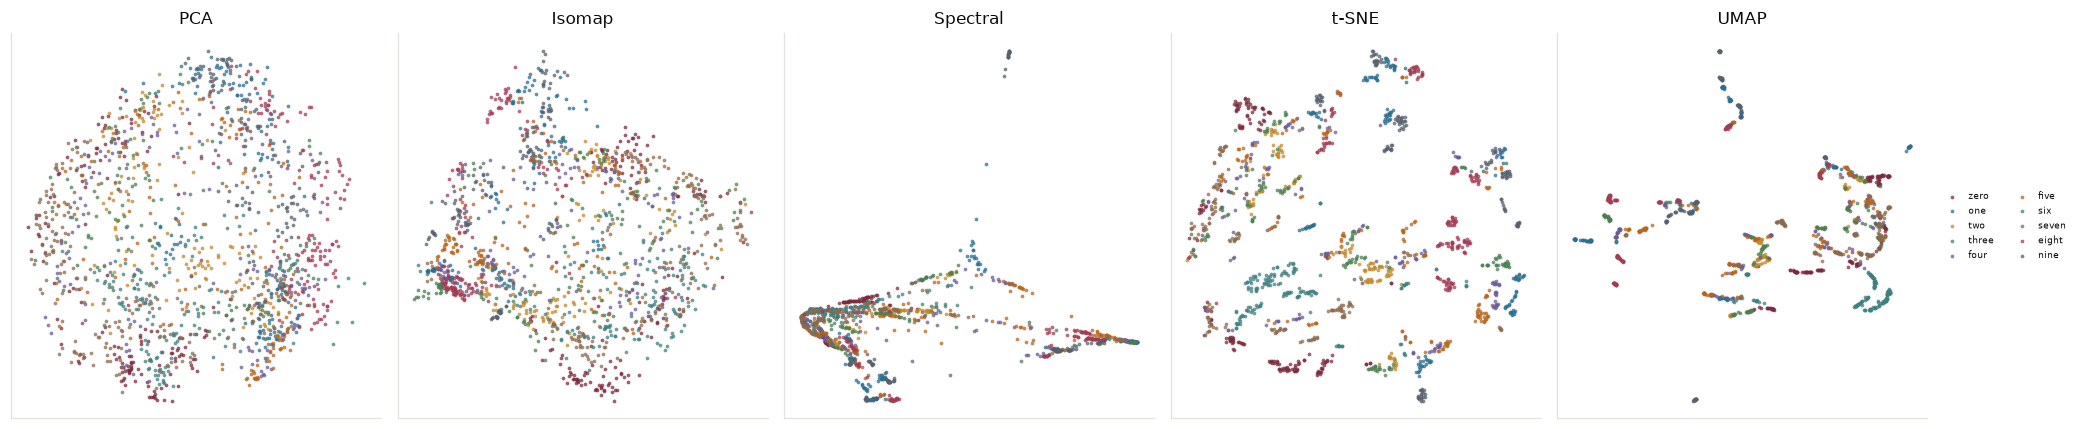

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(19, 4))
for ax, (name, Z) in zip(axes, embeddings.items()):
    plotting.embedding(Z, y, labels=data.DIGIT_KEYS, ax=ax, s=6)
    ax.set_title(name)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(ncol=2, fontsize=6, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plotting.savefig(fig, "02_embeddings", outdir="../plots")

t-SNE and UMAP look the most convincing. **That is exactly why they are dangerous.** Distances *between* clusters in those embeddings are not meaningful — the algorithms optimise local neighbourhoods and are free to place the resulting groups anywhere. Never quantify class separation on a t-SNE plot.

## Quantify instead

Three numbers per method. They measure different things and they come apart.

In [5]:
rows = []
for name, Z in embeddings.items():
    rows.append({
        "method": name,
        "trustworthiness": geometry.trustworthiness(Z50, Z, n_neighbors=15),
        "class_separation": geometry.class_separation(Z, y),
        "participation_ratio": geometry.participation_ratio(Z),
    })
table = pd.DataFrame(rows).set_index("method").round(3)
table

,trustworthiness,class_separation,participation_ratio
method,,,
PCA,0.905,0.541,1.922
Isomap,0.929,0.517,1.672
Spectral,0.949,0.233,2.000
t-SNE,0.994,0.443,1.872
UMAP,0.994,0.464,1.994


- **trustworthiness** — did the embedding preserve local neighbourhoods? (1 is perfect)
- **class_separation** — between-class scatter over within-class scatter. Is the structure it preserved *about the digit*?

A method can score well on the first and badly on the second. Those are different claims, and reporting only the picture hides the difference.

## The control you must run

Same pipeline, shuffled labels. If the embedding still looks structured, the structure is not about the digits.

class separation, true labels      0.464
class separation, shuffled labels  0.005


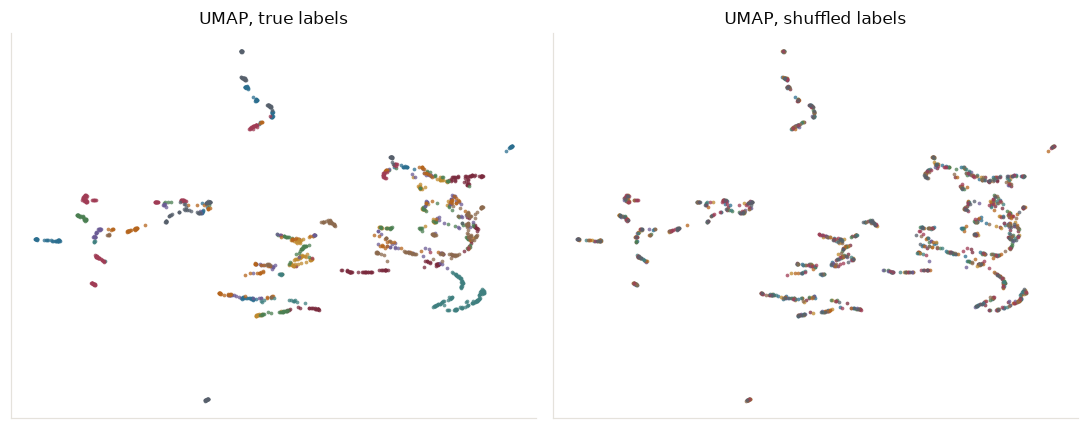

In [6]:
y_shuffled = rng.permutation(y)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plotting.embedding(embeddings["UMAP"], y, labels=data.DIGIT_KEYS, ax=axes[0], s=6)
axes[0].set_title("UMAP, true labels")
plotting.embedding(embeddings["UMAP"], y_shuffled, labels=data.DIGIT_KEYS, ax=axes[1], s=6)
axes[1].set_title("UMAP, shuffled labels")
for ax in axes:
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

print(f"class separation, true labels      {geometry.class_separation(embeddings['UMAP'], y):.3f}")
print(f"class separation, shuffled labels  {geometry.class_separation(embeddings['UMAP'], y_shuffled):.3f}")

The clusters are still there under shuffled labels — UMAP found *some* structure — but the class separation collapses. The clustering is real; its alignment with the digits is what the true-label number measures.

## Geometry across preprocessing conditions

Notebook 3 will regress decoding accuracy against these. Build the sweep now.

In [7]:
rows = []
for bin_ms in [10.0, 25.0, 50.0, 100.0]:
    for smooth_ms in [0.0, 20.0]:
        Xc, yc, _ = data.build_design_matrix(shd, bin_ms=bin_ms, t_max_ms=800.0,
                                             smooth_ms=smooth_ms, trials=subset)
        rows.append({"bin_ms": bin_ms, "smooth_ms": smooth_ms,
                     **geometry.summarize(data.flatten(Xc), yc)})

sweep = pd.DataFrame(rows)
sweep.round(3)

,bin_ms,smooth_ms,participation_ratio,class_separation,between_class_distance,within_class_radius
0,10.0,0.0,54.799,0.109,39.339,83.713
1,10.0,20.0,11.545,0.262,36.159,49.634
2,25.0,0.0,22.461,0.179,60.621,100.782
3,25.0,20.0,11.513,0.262,56.843,78.094
4,50.0,0.0,13.916,0.237,83.220,120.228
5,50.0,20.0,12.697,0.248,81.238,114.673
6,100.0,0.0,9.652,0.280,107.842,142.528
7,100.0,20.0,9.652,0.280,107.842,142.527


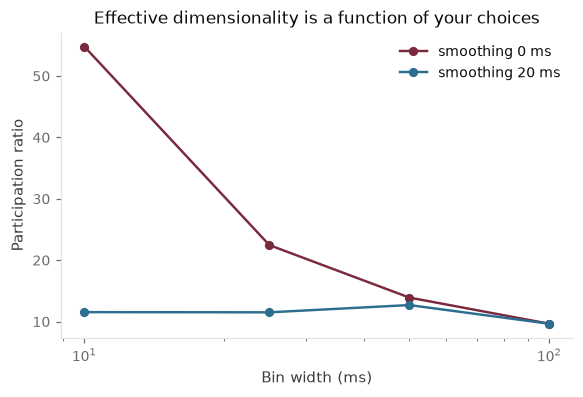

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for sm, grp in sweep.groupby("smooth_ms"):
    ax.plot(grp["bin_ms"], grp["participation_ratio"], marker="o", ms=5,
            label=f"smoothing {sm:g} ms")
ax.set_xscale("log")
ax.set_xlabel("Bin width (ms)")
ax.set_ylabel("Participation ratio")
ax.set_title("Effective dimensionality is a function of your choices")
ax.legend()

That figure is the point of this notebook. "The dimensionality of the representation" is not a property of the brain alone — it is a property of the brain *and* your preprocessing. Report both.

---

## Exercises

1. **Does trustworthiness predict class separation?** Plot one against the other across methods. If they are uncorrelated, say what that means for the practice of choosing a method because its plot looks good.
2. **Neighbourhood size.** Re-run Isomap and UMAP with `n_neighbors` in {5, 15, 50}. How much does the picture change? How much does the *number* change? Which would you report?
3. **Trajectories, not points.** Each trial is currently one point. Instead embed each *time bin* and draw the path a trial takes through the space. Do trials of the same digit follow similar paths?
4. **Factor analysis.** FA separates shared from private variance, which PCA does not. Does it change the effective-dimensionality estimate?

Next: **[3 · Decoding](03_decoding.ipynb)** — how much of this structure is usable.